### Fig. 7 - Variability in thickness gradient of $\sigma_0<26.5$ layer between 50N and 30N 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import cartopy
import os
import dask.config  
from scipy import stats
import gsw 
import warnings
warnings.filterwarnings("ignore")

#os.environ["OMP_NUM_THREADS"] = "8" 


In [3]:
# Throughput time series (1990-2017)

# Upload saved data (saved in part_quant_1990-2017.py)
dir_quant='YOUR_DATA_PATH' #directory for .csv file
df_spg = pd.read_csv(dir_quant+'vtSPG_an_1990-2017_data.csv') #read the CSV file 

VTanSPG = df_spg.vtSPG.values/1e+6/12 #annual mean VT in Sverdrup

In [4]:
# GO8p7-eORCA12 grid paths
data_path = 'YOUR_MODEL_DATA_PATH'
grid_path = 'YOUR_GRID_PATH'

ds93T = xr.open_dataset(data_path+'nemo_g8p7ho_1m_199301_grid-T.nc')
lev = ds93T.thetao_con.deptht
lat = ds93.nav_lat.values
lon = ds93.nav_lon.values
ds93.close()


In [ ]:
# Read in T, S, time varying DZ - compute potential density - store depth of isopycnal 26.5
files = [os.path.join(data_path, f) for f in os.listdir(data_path) if f.startswith('nemo_g8p7ho_1m_') and f.endswith('_grid-T.nc')]
files = sorted(files) #sort alphabetically
files = files[132:]  #1990-2021

# Lists to hold the data
depth_26p5_list = []
f=0

with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    for file in files: #loop over model data-paths
        f=f+1
        #print(f)
        
        ds = xr.open_dataset(file)
     
        temp = ds.thetao_con.squeeze(dim='time_counter').values
        sal  = ds.so_abs.squeeze(dim='time_counter').values
        thk  = ds.thkcello.squeeze("time_counter").values  
        
        dens = gsw.density.sigma0(sal, temp)
        
        valid = dens <= 26.5               #choose isopycnal 26.5

        ind = valid.cumsum(axis=0).argmax(axis=0)             # (y,x)
        has_valid = valid.any(axis=0)

        # Compute mid-depths
        z_interface = np.cumsum(thk, axis=0)                  # (z,y,x)
        z_mid = z_interface - thk/2                           # (z,y,x)

        # Fancy indexing
        ny, nx = ind.shape
        j, i = np.meshgrid(np.arange(ny), np.arange(nx), indexing="ij")
        out = np.where(has_valid, z_mid[ind, j, i], np.nan)   # (y,x)

        depth_26p5_list.append(out)
        
        ds.close()
        
depth_26p5_mon = np.stack(depth_26p5_list, axis=0)       
print(depth_26p5_mon.shape)

In [ ]:
del temp, sal, thk, valid, ind, has_valid
del out, z_interface, z_mid, depth_26p5_list 

In [ ]:
# Annual mean  
y=32 #number of years 1990-2021
ii=0 #count

Nt = len(depth_26p5_mon[:,0,0])
Ni = len(depth_26p5_mon[0,:,0])
Nj = len(depth_26p5_mon[0,0,:])

depth_26p5_an=np.zeros([y,Ni,Nj])

for m in range(0,Nt,12):
    depth_26p5_an[ii,:,:] = np.nanmean(depth_26p5_mon[m:m+12,:,:],axis=0) 
    ii=ii+1


In [ ]:
# Extract 30N and 50N latitude

# 30N 
latMin = 29.95; latMax = 30.05
lonMin = -81.5;   lonMax = -9

lat_ind30 = np.where( (lat >= latMin) & (lat <= latMax) )
lon_ind30 = np.where( (lon >= lonMin) & (lon <= lonMax) )

ind_lat30 = np.ravel_multi_index(lat_ind30,lon.shape)
ind_lon30 = np.ravel_multi_index(lon_ind30,lon.shape)

common_ind30 = np.intersect1d(ind_lat30, ind_lon30)

[ii30,jj30] = np.unravel_index(common_ind30,lon.shape)
jj30 = np.unique(jj30)
ii30 = np.repeat(ii30[0],len(jj30)) #choose a native grid line

# 50N
latMin = 49.95;  latMax = 50.05
lonMin = -55;   lonMax = -1

lat_ind50 = np.where( (lat >= latMin) & (lat <= latMax) )
lon_ind50 = np.where( (lon >= lonMin) & (lon <= lonMax) )

ind_lat50 = np.ravel_multi_index(lat_ind50,lon.shape)
ind_lon50 = np.ravel_multi_index(lon_ind50,lon.shape)

common_ind50 = np.intersect1d(ind_lat50, ind_lon50)

[ii50,jj50] = np.unravel_index(common_ind50,lon.shape)

jj50 = np.unique(jj50)
ii50 = np.repeat(ii50[0],len(jj50))

# Plot sections
from cartopy import crs
import cartopy.feature as cfeatures

data_proj = crs.PlateCarree( )  # Projection our data is in: data is in lon-lat coordinate system
display_proj = crs.Mercator( )  # Projection we want to display in

fig=plt.figure(figsize = (8,8))
ax = plt.axes( projection = display_proj ) 
ax.set_extent([-100,23,15,67],crs=data_proj)
ax.add_feature(cfeatures.LAND,edgecolor=(.3, .3, .3))#,color=(.7, .7, .7),zorder=2)
ax.scatter(lon[ii30,jj30],lat[ii30,jj30],s=0.5, color='blue', marker='o', transform=data_proj)
ax.scatter(lon[ii50,jj50],lat[ii50,jj50],s=0.5, color='blue', marker='o', transform=data_proj)
g1=ax.gridlines( draw_labels = True, linewidth = 1, color = 'gray',alpha = 0.3, linestyle = '--')  
g1.xlabels_bottom = False
g1.ylabels_right = False


In [ ]:
# Thickness at select latitudes time series
yrs = np.linspace(1990,2021,32)

thick30=np.nanmean(depth_26p5_an[:,ii30[0],jj30],axis=1)
thick50=np.nanmean(depth_26p5_an[:,ii50[0],jj50],axis=1)

diff_30N50N=thick50-thick30


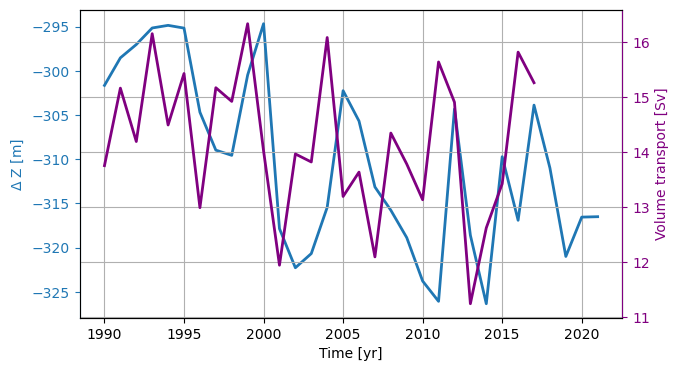

In [8]:
# Plotting Fig. 6

fig, ax1 = plt.subplots(1, 1, figsize=(7, 4))
ax1.plot(yrs,diff_30N50N,linewidth=2,label='..')
ax1.grid(axis='x')
ax1.set_xlabel('Time [yr]')
ax1.tick_params(axis='y', labelcolor='C0', colors='C0')
ax1.spines['left'].set_color('C0')
ax1.set_ylabel('$\Delta$ Z [m]', color='C0')
#
ax2 = ax1.twinx()
ax2.patch.set_visible(False)  
#
ax2.plot(df_spg.year.values,df_spg.vtSPG.values/1e+6/12,color='Purple',linewidth=2,label='Throughput') 
ax2.grid(axis='y') 
ax2.tick_params(axis='y', labelcolor='Purple', colors='Purple')
ax2.spines['right'].set_color('Purple')
ax2.set_ylabel('Volume transport [Sv]', color='Purple')
#
ax1.spines['left'].set_color('C0')


In [10]:
# Correlations
print(stats.pearsonr(df_spg.vtSPG.values,diff_30N50N[0:28]))   #ns
print(stats.pearsonr(df_spg.vtSPG.values,diff_30N50N[1:28+1])) #r=0.63 (highest corr.)
print(stats.pearsonr(df_spg.vtSPG.values,diff_30N50N[2:28+2])) #ns


PearsonRResult(statistic=0.3427996685602938, pvalue=0.07413495217071348)
PearsonRResult(statistic=0.6283435128635475, pvalue=0.0003430088956603701)
PearsonRResult(statistic=0.18544904426201483, pvalue=0.34476371919042936)
